# Final test

The tuned union configuration is refit on train and validation, then scored once on the test
vintages. The test set was not used to select the features, model or parameters.

This notebook:

- Reports ROC AUC, PR AUC, Brier score and log-loss on test alongside the validation figures from
  notebook 24.
- Compares predicted and observed default rates on validation and test, including the parts of the
  score distribution used by the decision rules.
- Applies the three policies from notebook 23 to realised test outcomes and compares their
  results.
- Adds confidence intervals to the test metrics, calibration gaps and policy-profit differences,
  with uncertainty bands on the reliability curves.
  The fitted model and decision rules remain fixed throughout these comparisons.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import bootstrap
from sklearn.metrics import log_loss

from credit_risk.data import load_loans, load_outcomes
from credit_risk.split import out_of_time_split
from credit_risk.model import (
    build_lgbm,
    UNDERWRITER_NUMERIC, UNDERWRITER_CATEGORICAL,
    LC_VERDICT_NUMERIC, LC_VERDICT_CATEGORICAL,
)
from credit_risk.evaluate import (
    discrimination_metrics,
    reliability_data,
    reliability_intervals,
    expected_profit,
    breakeven_probability,
)

TARGET = "target_bad"
NUMERIC = UNDERWRITER_NUMERIC + LC_VERDICT_NUMERIC
CATEGORICAL = UNDERWRITER_CATEGORICAL + LC_VERDICT_CATEGORICAL
COLS = NUMERIC + CATEGORICAL

df = load_loans()
train, val, test = out_of_time_split(df)
train_val = pd.concat([train, val])

best = json.loads((Path("..") / "reports" / "lgbm_best_params.json").read_text())
final = build_lgbm(NUMERIC, CATEGORICAL, params=best)
final.fit(train_val[COLS], train_val[TARGET])

test = test.assign(proba=final.predict_proba(test[COLS])[:, 1])
print(f"train+val {len(train_val)}, test {len(test)}, test bad rate {test[TARGET].mean():.3f}")

train+val 529915, test 178453, test bad rate 0.155


## Out of sample

The tuned configuration reached a ROC AUC of 0.699, a PR AUC of 0.279 and a log-loss of 0.392 on
validation in notebook 24. Validation contributed to parameter selection, while the test set
provides the post-selection evaluation on later vintages. The test bad rate also differs from
validation, which affects the interpretation of PR AUC. The metrics are therefore reported for
each split without treating their difference as a direct measure of improvement.

The point estimates below describe this test book. The following intervals assess their
precision, conditional on the fitted model and the observed test vintages.

In [2]:
metrics = discrimination_metrics(test[TARGET], test["proba"])
metrics["log_loss"] = log_loss(test[TARGET], test["proba"])
pd.Series(metrics).round(4)

roc_auc     0.7099
pr_auc      0.3031
brier       0.1214
log_loss    0.3950
dtype: float64

### Uncertainty in test performance

We resample the test loans with replacement, keeping each loan's outcome and predicted probability together. The fitted model remains fixed. The table shows the metrics on the full test set and 95% confidence intervals, given by the 2.5th and 97.5th percentiles of 1,000 bootstrap samples with seed 0.

These intervals describe sampling uncertainty within the test period. They do not include model refitting, future-vintage drift or a comparison with validation performance.

In [3]:
# Returns the four metrics for one sample of test loans.
def test_metrics(y, proba):
    return list(discrimination_metrics(y, proba).values()) + [log_loss(y, proba)]


intervals = bootstrap(
    (test[TARGET], test["proba"]), test_metrics, paired=True, vectorized=False,
    n_resamples=1000, batch=20, method="percentile", rng=0,
).confidence_interval

print(f"{len(test):,} test loans, 1,000 paired bootstrap samples")
pd.DataFrame({
    "estimate": list(metrics.values()),
    "ci_low": intervals.low,
    "ci_high": intervals.high,
}, index=metrics).round(4)

178,453 test loans, 1,000 paired bootstrap samples


,estimate,ci_low,ci_high
roc_auc,0.7099,0.7066,0.7130
pr_auc,0.3031,0.2978,0.3082
brier,0.1214,0.1203,0.1226
log_loss,0.3950,0.3919,0.3981


The intervals keep ROC AUC close to 0.71 and PR AUC close to 0.30. Sampling variability within
this test period is modest around the headline scores. The ranking estimates are therefore
fairly precise for this period, but do not establish improvement over validation or stability
across future vintages.

## Calibration

The expected-profit rule uses predicted default probabilities directly, so its decisions depend
on the relationship between predicted and observed default rates. The comparison below reports
their means on validation and test, plots both reliability curves, and checks the same
relationship by interest rate and around the two decision thresholds.

Each table includes a 95% bootstrap interval for the mean gap, observed minus predicted default
rate. A positive interval supports underprediction on that group. As above, each interval uses
1,000 samples with seed 0, keeping outcomes and predictions paired. The existing rate bands are
fixed, and the validation intervals remain descriptive because validation also served tuning.

The curves show 95% pointwise bootstrap intervals for the observed default rate in each of the
existing ten quantile bins, using 1,000 resamples with seed 0. Predictions and bin boundaries
remain fixed, and validation and test are resampled separately. The shaded bands describe
uncertainty in each bin's observed rate; the tables estimate observed-minus-predicted gaps
directly. The bands do not give 95% coverage for the entire curve or measure future drift.

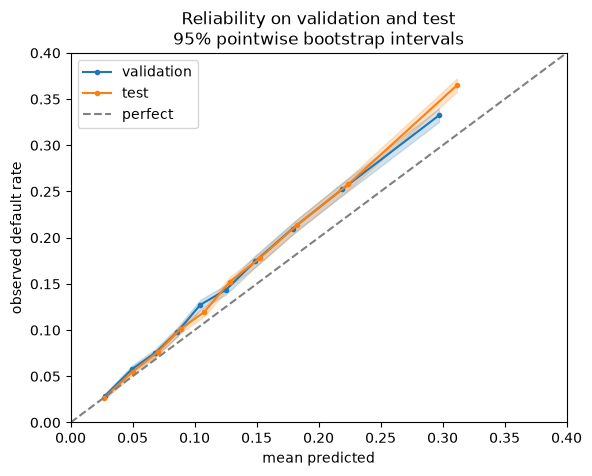

,mean_prediction,observed_rate,mean_gap,gap_ci_low,gap_ci_high,top_bin_prediction,top_bin_observed
validation,0.130533,0.150016,0.019483,0.017710,0.021188,0.297036,0.332364
test,0.134365,0.154640,0.020275,0.018645,0.022034,0.311482,0.364900


,loans,mean_prediction,observed_rate,gap,gap_ci_low,gap_ci_high
int_rate,,,,,,
"[0.0, 10.0)",82146,0.0739,0.0794,0.0055,0.0037,0.0073
"[10.0, 15.0)",69325,0.1590,0.1834,0.0244,0.0217,0.0273
"[15.0, 20.0)",23412,0.2432,0.2934,0.0502,0.0445,0.0565
"[20.0, inf)",3570,0.3314,0.4165,0.0851,0.0695,0.1012


In [4]:
# Estimates an interval for the mean observed-minus-predicted default rate.
def gap_interval(frame: pd.DataFrame):
    return bootstrap(
        (frame[TARGET] - frame["proba"],), np.mean,
        n_resamples=1000, batch=20, method="percentile", rng=0,
    ).confidence_interval


validation_model = build_lgbm(NUMERIC, CATEGORICAL, params=best)
validation_model.fit(train[COLS], train[TARGET])
validation = val.assign(proba=validation_model.predict_proba(val[COLS])[:, 1])

calibration_rows = {}
for name, frame in [("validation", validation), ("test", test)]:
    prob_true, prob_pred = reliability_data(frame[TARGET], frame["proba"])
    interval = gap_interval(frame)
    calibration_rows[name] = {
        "mean_prediction": frame["proba"].mean(),
        "observed_rate": frame[TARGET].mean(),
        "mean_gap": frame[TARGET].mean() - frame["proba"].mean(),
        "gap_ci_low": interval.low,
        "gap_ci_high": interval.high,
        "top_bin_prediction": prob_pred[-1],
        "top_bin_observed": prob_true[-1],
    }
    ci_low, ci_high = reliability_intervals(frame[TARGET], frame["proba"])
    line, = plt.plot(prob_pred, prob_true, marker="o", markersize=3, label=name)
    plt.fill_between(prob_pred, ci_low, ci_high, color=line.get_color(), alpha=0.2)

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="perfect")
plt.xlim(0, 0.4)
plt.ylim(0, 0.4)
plt.xlabel("mean predicted")
plt.ylabel("observed default rate")
plt.title("Reliability on validation and test\n95% pointwise bootstrap intervals")
plt.legend()

out = Path("..") / "reports" / "reliability_test.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()

display(pd.DataFrame(calibration_rows).T)

rate_band = pd.cut(test["int_rate"], [0, 10, 15, 20, float("inf")], right=False)
rate_calibration = test.groupby(rate_band, observed=True).agg(
    loans=(TARGET, "size"),
    mean_prediction=("proba", "mean"),
    observed_rate=(TARGET, "mean"),
)
rate_calibration["gap"] = (
    rate_calibration["observed_rate"] - rate_calibration["mean_prediction"]
)

rate_calibration[["gap_ci_low", "gap_ci_high"]] = [
    gap_interval(part) for _, part in test.groupby(rate_band, observed=True)
]
rate_calibration.round(4)

The test mean gap is 2.03 percentage points, with a 95% interval of 1.86 to 2.20 points.
Underprediction is also present in each existing interest-rate band: all four intervals are
positive. The gap reaches 8.51 points in the 20%+ band, but its interval is wider, from 6.95 to
10.12 points, with only 3,570 loans. The direction is clear within these groups; the magnitude
is less precisely estimated at the highest rates.

## What it is worth

This section applies the three policies from notebook 23 to realised test outcomes. The single
break-even threshold is calculated from the amount-weighted average rate in train and validation,
without using test data. The results show whether the ordering of the policies on validation
carries to the test vintages.

In the table, `profit_per_loan` is measured per approved loan. The paired comparisons below
assess the precision of the total-profit differences while keeping all three policies fixed.

In [5]:
outcomes = load_outcomes().drop(columns=["loan_amnt"])
scored = test.merge(outcomes, on="id")
assert len(scored) == len(test)

scored["realised_profit"] = (
    scored["total_rec_prncp"] + scored["recoveries"] + scored["total_rec_int"] - scored["loan_amnt"]
)
scored["exp_profit"] = expected_profit(scored["proba"], scored["loan_amnt"], scored["int_rate"])

r_bar = (train_val["int_rate"] * train_val["loan_amnt"]).sum() / train_val["loan_amnt"].sum()
c = breakeven_probability(r_bar)
print(f"single break-even: {c:.3f}, from an average rate of {r_bar:.1f}%")

policies = {
    "approve all": pd.Series(True, index=scored.index),
    "single break-even": scored["proba"] < c,
    "expected profit": scored["exp_profit"] > 0,
}

rows = {}
for name, approve in policies.items():
    taken = scored[approve]
    rows[name] = {
        "approved": len(taken),
        "total_profit": taken["realised_profit"].sum(),
        "profit_per_loan": taken["realised_profit"].mean(),
        "bad_rate": taken[TARGET].mean(),
    }

policy_results = pd.DataFrame(rows).T
display(policy_results)

single break-even: 0.310, from an average rate of 12.0%


,approved,total_profit,profit_per_loan,bad_rate
approve all,178453.0,1.249339e+08,700.094229,0.154640
single break-even,171276.0,1.297716e+08,757.675511,0.143488
expected profit,177219.0,1.264917e+08,713.759252,0.152630


### Uncertainty in the policy comparisons

We use the paired bootstrap from notebook 23. Under each policy, an approved loan contributes its realised profit and a rejected loan contributes zero. We calculate each loan's profit difference between two policies and resample these differences, keeping the comparison paired. The model, thresholds and approval decisions remain fixed.

Each table shows the difference measured on the full test book and a 95% confidence interval, given by the 2.5th and 97.5th percentiles of 1,000 bootstrap samples with seed 0. Differences are calculated as first minus second, so positive values favour the first policy. Amounts are in millions.

All test loans are included. The intervals describe sampling variability for comparable books of the same size, conditional on the fitted model and fixed policies. They do not cover future-vintage drift or uncertainty in the economic assumptions. These comparisons report the pre-specified rules without using test outcomes to adjust them.

In [6]:
profits = pd.DataFrame({
    name: scored["realised_profit"].where(approve, 0)
    for name, approve in policies.items()
})
comparisons = {
    "single break-even - approve all": ("single break-even", "approve all"),
    "expected profit - approve all": ("expected profit", "approve all"),
    "single break-even - expected profit": ("single break-even", "expected profit"),
}

print(f"{len(scored):,} test loans, 1,000 paired bootstrap samples")
for name, (first, second) in comparisons.items():
    difference = profits[first] - profits[second]
    interval = bootstrap(
        (difference,), np.sum, n_resamples=1000, batch=20, method="percentile", rng=0,
    ).confidence_interval

    print(name)
    display(pd.DataFrame({
        "difference": [difference.sum() / 1e6],
        "ci_low": [interval.low / 1e6],
        "ci_high": [interval.high / 1e6],
    }, index=["profit (M)"]).round(3))

178,453 test loans, 1,000 paired bootstrap samples


single break-even - approve all


,difference,ci_low,ci_high
profit (M),4.838,3.836,5.903


expected profit - approve all


,difference,ci_low,ci_high
profit (M),1.558,1.14,1.997


single break-even - expected profit


,difference,ci_low,ci_high
profit (M),3.28,2.386,4.232


All three intervals are above zero. The single break-even rule gains 4.838M over approving
every loan, with a 95% interval of 3.836M to 5.903M, and 3.280M over the per-loan rule, with an
interval of 2.386M to 4.232M. The per-loan rule also improves on approving all: its 1.558M gain
has an interval of 1.140M to 1.997M.

The test comparisons therefore support the same policy ordering as the validation point
estimates. The per-loan rule's advantage over approving all was uncertain on validation; here
its interval is positive. This strengthens that comparison on the test book, without establishing
that the advantage increased between periods or that the ordering will persist on future books.

### Around the decision thresholds

The first table checks the existing groups within one percentage point of each threshold. It
reports their loan counts and intervals for observed minus predicted default rate, using the
same bootstrap as the calibration section. The following tables examine loans approved only by
the per-loan rule and compare predicted profit, profit using observed outcomes and realised
cash flows.

In [7]:
own_cutoff = breakeven_probability(scored["int_rate"])
near_cutoff = {
    "single threshold": (scored["proba"] - c).abs() <= 0.01,
    "per-loan threshold": (scored["proba"] - own_cutoff).abs() <= 0.01,
}
decision_rows = {}
for name, mask in near_cutoff.items():
    part = scored[mask]
    interval = gap_interval(part)
    decision_rows[name] = {
        "loans": len(part),
        "mean_prediction": part["proba"].mean(),
        "observed_rate": part[TARGET].mean(),
        "gap": (part[TARGET] - part["proba"]).mean(),
        "gap_ci_low": interval.low,
        "gap_ci_high": interval.high,
    }
display(pd.DataFrame(decision_rows).T.round(4))

flat = scored["proba"] < c
per_loan = scored["exp_profit"] > 0
extra = scored[per_loan & ~flat]
disagreement = pd.Series({
    "loans": len(extra),
    "mean_rate": extra["int_rate"].mean(),
    "mean_prediction": extra["proba"].mean(),
    "observed_rate": extra[TARGET].mean(),
    "realised_profit": extra["realised_profit"].sum(),
}, name="approved only by per-loan rule")
display(disagreement.to_frame("value"))

profit_check = pd.Series({
    "training payoff at predicted probabilities": expected_profit(
        extra["proba"], extra["loan_amnt"], extra["int_rate"]
    ).sum(),
    "training payoff at observed outcomes": expected_profit(
        extra[TARGET], extra["loan_amnt"], extra["int_rate"]
    ).sum(),
    "realised cash flows": extra["realised_profit"].sum(),
}, name="total_profit")
profit_check

,loans,mean_prediction,observed_rate,gap,gap_ci_low,gap_ci_high
single threshold,2429.0,0.3098,0.3623,0.0525,0.0341,0.0711
per-loan threshold,826.0,0.3601,0.3753,0.0152,-0.0184,0.0506


,value
loans,6.066000e+03
mean_rate,1.933905e+01
mean_prediction,3.534415e-01
observed_rate,4.129575e-01
realised_profit,-3.300529e+06


training payoff at predicted probabilities    3.142116e+06
training payoff at observed outcomes         -2.428952e+05
realised cash flows                          -3.300529e+06
Name: total_profit, dtype: float64

Around the single threshold, the observed default rate exceeds the prediction by 5.25 percentage
points, with a 95% interval of 3.41 to 7.11 points. Around the per-loan threshold, the estimated
gap is 1.52 points and the interval runs from -1.84 to 5.06 points. With only 826 loans, that
local comparison is inconclusive: the overall underprediction does not justify an equally
strong claim at both thresholds.

The per-loan rule alone approves 6,066 loans with a mean rate of 19.3%. Their observed default
rate is 41.3%, against 35.3% predicted, and their realised profit is -3.3M. Replacing predicted
probabilities with observed outcomes reduces the assumed profit from 3.1M to -0.2M; replacing
the assumed payoffs with realised cash flows takes it to -3.3M. Both probability underprediction
and the payoff assumptions contribute to this diagnostic, so the policy gap cannot be attributed
to calibration alone.

## Conclusions

The model records a test ROC AUC of 0.710, with a 95% bootstrap interval of 0.707 to 0.713,
and a PR AUC of 0.303, with an interval of 0.298 to 0.308. These are fairly precise estimates
of ranking performance on this test period. The validation figures of 0.699 and 0.279 describe
a different split used in model selection; the comparison does not establish an improvement.

Underprediction is present on both splits. The model predicts a mean default rate of 13.1%
against 15.0% observed on validation, and 13.4% against 15.5% on test. The test gap is about
2.03 percentage points, with an interval of 1.86 to 2.20 points, and all existing rate bands
also have positive intervals. Near the single threshold, the gap is clearly positive; near
the per-loan threshold, the smaller sample leaves the direction uncertain. The aggregate
calibration result should therefore not be extended equally to both decision regions. Test
Brier score and log-loss are 0.121 and 0.395; these scores do not isolate calibration.

The single break-even policy earns 129.8M on test, compared with 126.5M for per-loan expected
profit and 124.9M for approving every loan. All three paired profit differences have positive
intervals, supporting this ordering on comparable test-period books. The single rule's advantage
over the per-loan rule is 3.280M, with an interval of 2.386M to 4.232M. The disagreement
diagnostics point to both probability underprediction and payoff assumptions, rather than
calibration alone.

The reliability bands show uncertainty within each score bin; the gap intervals support
the underprediction conclusions. The fitted model and policies remain fixed throughout
the bootstrap. The intervals cover sampling uncertainty within the observed vintages, not
model refitting or future drift. The scope remains Lending Club's approved loans, with no
discounting and the recovery behaviour observed in past loans. The policy result applies
within that scope.